In [2]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def cargar_datos(zip_path="CERN_dataset.zip", carpeta_salida="CERN_datos"):
    #1. Proceso para descomprimir el archivo ZIP
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(carpeta_salida)
    X = []
    y = []
    #2. Recorrer las carpetas con las imagenes
    for clase in os.listdir(carpeta_salida):
        clase_path = os.path.join(carpeta_salida, clase)
        if os.path.isdir(clase_path):
            for img_name in os.listdir(clase_path):
                img_path = os.path.join(clase_path, img_name)

                # 3. Procedimiento para cargar imagenes en escala de grises
                img = Image.open(img_path).convert("L")
                X.append(np.array(img))
                y.append(clase)  # etiqueta = nombre de la carpeta

    X = np.array(X)
    return X, y

In [3]:
X, y = cargar_datos("CERN_dataset.zip")
print(f"Se cargaron {len(X)} imágenes.")
print(f"Clases encontradas: {set(y)}")
print("Dimensiones de las imágenes:", X.shape)

Se cargaron 60000 imágenes.
Clases encontradas: {'electron', 'proton', 'neutrino', 'muon', 'quark', 'tau'}
Dimensiones de las imágenes: (60000, 64, 64)


## **Clasificación de Trazas de Partículas**

Construya un clasificador supervisado capaz de diferenciar entre distintos tipos de partículas a partir de imágenes de sus trazas. Para ello, se trabajará con el conjunto de datos previamente cargado, organizadas en carpetas según la clase de partícula correspondiente:

*   Electrón
*   Muón
*   Protón
*   Neutrino
*   Quark
*   Tau

Desarrolle un flujo completo de trabajo en aprendizaje automático, desde la carga y exploración de los datos hasta la evaluación de un modelo de clasificación. El ejercicio permitirá comprender los principales pasos de un proyecto de machine learning aplicado al análisis de imágenes.

1. Carga de datos.
2. Exploración inicial: Se deberán mostrar algunas imágenes representativas de cada clase, imprimir las dimensiones de X y y, y analizar la distribución de las clases en el conjunto de datos.
3. Será necesario normalizar los valores de los píxeles en el rango [0, 1], preparar los datos para el modelo y dividirlos en conjuntos de entrenamiento y prueba (por ejemplo, 80% entrenamiento y 20% prueba).
4. Implemente al menos un modelo de clasificación supervisada. Se recomienda iniciar con modelos clásicos como: Regresión Logística y SVM.
5. Evaluación del modelo: El desempeño del clasificador deberá medirse calculando la precisión en el conjunto de prueba. Además, se deberá generar una matriz de confusión para analizar qué clases resultan más fáciles o difíciles de distinguir. Pueden calcular métricas adicionales como la exactitud por clase o las curvas ROC.
6. Discusión y conclusiones: Finalmente, deberá presentar una reflexión sobre los resultados obtenidos, identificando fortalezas y debilidades del clasificador. También deberá proponer mejoras posibles.

In [6]:
# Paso 1: Carga de datos
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from collections import Counter

# Función para cargar imágenes
def load_image_dataset(root_dir, size=(64,64), max_per_class=None):
    X, y = [], []
    classes = sorted(os.listdir(root_dir))
    for cls in classes:
        cls_path = os.path.join(root_dir, cls)
        if not os.path.isdir(cls_path):
            continue
        files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png','.jpg'))]
        if max_per_class:
            files = files[:max_per_class]
        for f in files:
            img = imread(os.path.join(cls_path, f))
            if img.ndim == 3:  # convertir a escala de grises si es RGB
                img = img[...,0]
            img_resized = resize(img, size, anti_aliasing=True)
            X.append(img_resized)
            y.append(cls)
    return np.array(X), np.array(y), classes

# Cambia la ruta por la carpeta donde tengas las imágenes
X, y, classes = load_image_dataset("CMS_data", size=(64,64))
print("Shape de X:", X.shape)
print("Shape de y:", y.shape)
print("Clases:", classes)


Shape de X: (60000, 64, 64)
Shape de y: (60000,)
Clases: ['electron', 'muon', 'neutrino', 'proton', 'quark', 'tau']


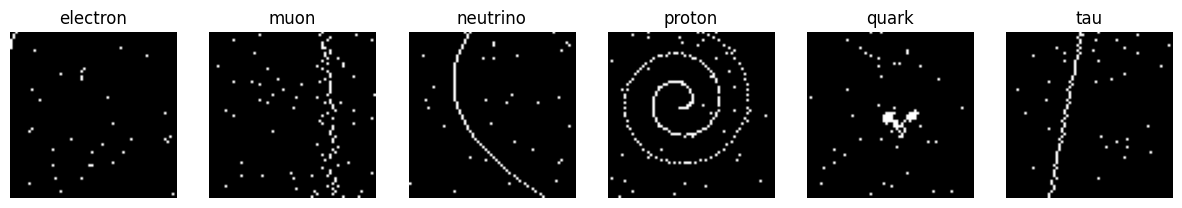

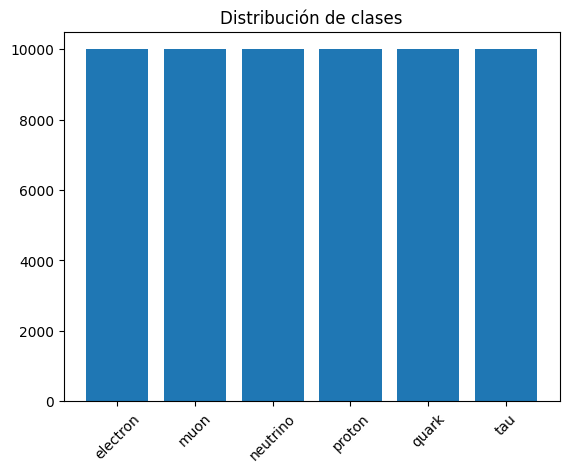

In [7]:
# Paso 2: Exploración inicial
# Mostrar algunas imágenes representativas por clase
fig, axes = plt.subplots(1, len(classes), figsize=(15,4))
for i, cls in enumerate(classes):
    idx = np.where(y == cls)[0][0]  # primer ejemplo de esa clase
    axes[i].imshow(X[idx], cmap="gray")
    axes[i].set_title(cls)
    axes[i].axis("off")
plt.show()

# Distribución de clases
conteo = Counter(y)
plt.bar(conteo.keys(), conteo.values())
plt.xticks(rotation=45)
plt.title("Distribución de clases")
plt.show()

In [8]:
# Paso 3: Normalización y división de datos
# Normalizar al rango [0,1]
X = X / X.max()

# Aplanar imágenes para modelos clásicos
X_flat = X.reshape(len(X), -1)

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y, test_size=0.2, stratify=y, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (48000, 4096) Test: (12000, 4096)


In [ ]:
# Instalar librerías necesarias para HPO
!pip install scikit-optimize hyperopt sklearn-genetic optuna
!pip install pyswarm  # Para Particle Swarm Optimization

In [ ]:
# Importaciones para HPO
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import loguniform, randint
import warnings
warnings.filterwarnings('ignore')
import time
import pandas as pd

# Configuración para paralelización
n_jobs = -1  # Usar todos los núcleos disponibles
cv = 3
max_iter = 500

In [ ]:
# Espacios de búsqueda optimizados para cada modelo
param_spaces = {
    'LogisticRegression': {
        'C': loguniform(1e-4, 1e4),
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga'],
        'max_iter': [max_iter]
    },
    'SVC': {
        'C': loguniform(1e-4, 1e4),
        'kernel': ['linear', 'rbf'],
        'gamma': loguniform(1e-6, 1e1),
        'max_iter': [max_iter]
    }
}

print("Espacios de búsqueda configurados para:")
print("- LogisticRegression")
print("- SVC")

In [ ]:
# Escalar características - CRUCIAL para HPO
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Datos escalados:")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled: {X_test_scaled.shape}")
print(f"Media X_train_scaled: {np.mean(X_train_scaled):.4f}")
print(f"Desviación X_train_scaled: {np.std(X_train_scaled):.4f}")

In [ ]:
def grid_search_hpo(X_train, y_train, model_class):
    """Grid Search - Búsqueda exhaustiva en grid definido"""
    print(f"Ejecutando Grid Search para {model_class}...")
    
    if model_class == 'LogisticRegression':
        param_grid = {
            'C': [0.1, 1, 10, 100],
            'penalty': ['l1', 'l2'],
            'solver': ['liblinear', 'saga'],
            'max_iter': [max_iter]
        }
    else:  # SVC
        param_grid = {
            'C': [0.1, 1, 10, 100],
            'kernel': ['linear', 'rbf'],
            'gamma': ['scale', 'auto', 0.1, 0.01],
            'max_iter': [max_iter]
        }
    
    model = LogisticRegression() if model_class == 'LogisticRegression' else SVC()
    
    grid = GridSearchCV(
        model, param_grid, 
        cv=cv, 
        n_jobs=n_jobs, 
        scoring='accuracy',
        verbose=1
    )
    
    grid.fit(X_train, y_train)
    
    print(f"Grid Search - Mejores parámetros: {grid.best_params_}")
    print(f"Grid Search - Mejor score: {grid.best_score_:.4f}")
    
    return grid.best_params_, grid.best_score_

In [ ]:
def random_search_hpo(X_train, y_train, model_class):
    """Random Search - Búsqueda aleatoria en distribución de parámetros"""
    print(f"Ejecutando Random Search para {model_class}...")
    
    param_dist = param_spaces[model_class]
    model = LogisticRegression() if model_class == 'LogisticRegression' else SVC()
    
    random_search = RandomizedSearchCV(
        model, param_dist, 
        n_iter=10,  # Número de combinaciones aleatorias
        cv=cv, 
        n_jobs=n_jobs, 
        scoring='accuracy',
        random_state=42,
        verbose=1
    )
    
    random_search.fit(X_train, y_train)
    
    print(f"Random Search - Mejores parámetros: {random_search.best_params_}")
    print(f"Random Search - Mejor score: {random_search.best_score_:.4f}")
    
    return random_search.best_params_, random_search.best_score_

In [ ]:
def bayesian_optimization_hpo(X_train, y_train, model_class):
    """Bayesian Optimization usando scikit-optimize"""
    try:
        from skopt import BayesSearchCV
        from skopt.space import Real, Categorical, Integer
        
        print(f"Ejecutando Bayesian Optimization para {model_class}...")
        
        if model_class == 'LogisticRegression':
            search_spaces = {
                'C': Real(1e-4, 1e4, prior='log-uniform'),
                'penalty': Categorical(['l1', 'l2']),
                'solver': Categorical(['liblinear', 'saga']),
                'max_iter': Integer(100, 1000)
            }
        else:  # SVC
            search_spaces = {
                'C': Real(1e-4, 1e4, prior='log-uniform'),
                'kernel': Categorical(['linear', 'rbf']),
                'gamma': Real(1e-6, 1e1, prior='log-uniform'),
                'max_iter': Integer(100, 1000)
            }
        
        model = LogisticRegression() if model_class == 'LogisticRegression' else SVC()
        
        bayes_search = BayesSearchCV(
            model, search_spaces,
            n_iter=10,  # Número de iteraciones
            cv=cv,
            n_jobs=n_jobs,
            scoring='accuracy',
            random_state=42,
            verbose=1
        )
        
        bayes_search.fit(X_train, y_train)
        
        print(f"Bayesian Optimization - Mejores parámetros: {bayes_search.best_params_}")
        print(f"Bayesian Optimization - Mejor score: {bayes_search.best_score_:.4f}")
        
        return bayes_search.best_params_, bayes_search.best_score_
    
    except ImportError as e:
        print(f"Error: {e}")
        print("Instala scikit-optimize: !pip install scikit-optimize")
        return None, 0

In [ ]:
def genetic_algorithm_hpo(X_train, y_train, model_class):
    """Algoritmos Genéticos usando sklearn-genetic"""
    try:
        from sklearn_genetic import GASearchCV
        from sklearn_genetic.space import Continuous, Categorical, Integer
        
        print(f"Ejecutando Genetic Algorithm para {model_class}...")
        
        if model_class == 'LogisticRegression':
            param_grid = {
                'C': Continuous(1e-4, 1e4),
                'penalty': Categorical(['l1', 'l2']),
                'solver': Categorical(['liblinear', 'saga']),
                'max_iter': Integer(100, 1000)
            }
        else:  # SVC
            param_grid = {
                'C': Continuous(1e-4, 1e4),
                'kernel': Categorical(['linear', 'rbf']),
                'gamma': Continuous(1e-6, 1e1),
                'max_iter': Integer(100, 1000)
            }
        
        model = LogisticRegression() if model_class == 'LogisticRegression' else SVC()
        
        evolved_estimator = GASearchCV(
            model,
            cv=cv,
            scoring='accuracy',
            param_grid=param_grid,
            n_jobs=n_jobs,
            verbose=True,
            population_size=10,
            generations=8,
            tournament_size=3,
            elitism=True,
            random_state=42
        )
        
        evolved_estimator.fit(X_train, y_train)
        
        print(f"Genetic Algorithm - Mejores parámetros: {evolved_estimator.best_params_}")
        print(f"Genetic Algorithm - Mejor score: {evolved_estimator.best_score_:.4f}")
        
        return evolved_estimator.best_params_, evolved_estimator.best_score_
    
    except ImportError as e:
        print(f"Error: {e}")
        print("Instala sklearn-genetic: !pip install sklearn-genetic")
        return None, 0

In [ ]:
def particle_swarm_hpo(X_train, y_train, model_class):
    """Particle Swarm Optimization usando pyswarm"""
    try:
        from pyswarm import pso
        
        print(f"Ejecutando Particle Swarm Optimization para {model_class}...")
        
        def objective_function(params):
            if model_class == 'LogisticRegression':
                model = LogisticRegression(
                    C=max(params[0], 1e-4),
                    penalty='l2',
                    solver='liblinear',
                    max_iter=max_iter,
                    random_state=42
                )
            else:  # SVC
                model = SVC(
                    C=max(params[0], 1e-4),
                    kernel='rbf',
                    gamma=max(params[1], 1e-6),
                    max_iter=max_iter,
                    random_state=42
                )
            
            try:
                scores = cross_val_score(model, X_train, y_train, cv=cv, 
                                       n_jobs=n_jobs, scoring='accuracy')
                return -np.mean(scores)  # Minimizar negativo de accuracy
            except:
                return 1.0  # Penalización si falla
            
        # Límites para los parámetros
        if model_class == 'LogisticRegression':
            lb = [1e-4]  # C
            ub = [1e4]
            n_particles = 5
        else:  # SVC
            lb = [1e-4, 1e-6]  # C, gamma
            ub = [1e4, 1e1]
            n_particles = 8
        
        best_params, best_score = pso(
            objective_function, lb, ub, 
            swarmsize=n_particles, 
            maxiter=5,  # Iteraciones
            debug=True
        )
        
        # Reconstruir parámetros completos
        if model_class == 'LogisticRegression':
            final_params = {
                'C': best_params[0],
                'penalty': 'l2',
                'solver': 'liblinear',
                'max_iter': max_iter
            }
        else:
            final_params = {
                'C': best_params[0],
                'kernel': 'rbf',
                'gamma': best_params[1],
                'max_iter': max_iter
            }
        
        final_score = -best_score
        
        print(f"Particle Swarm - Mejores parámetros: {final_params}")
        print(f"Particle Swarm - Mejor score: {final_score:.4f}")
        
        return final_params, final_score
    
    except ImportError as e:
        print(f"Error: {e}")
        print("Instala pyswarm: !pip install pyswarm")
        return None, 0

In [ ]:
def tpe_hpo(X_train, y_train, model_class):
    """Tree-structured Parzen Estimator usando hyperopt"""
    try:
        from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
        
        print(f"Ejecutando TPE para {model_class}...")
        
        if model_class == 'LogisticRegression':
            space = {
                'C': hp.loguniform('C', np.log(1e-4), np.log(1e4)),
                'penalty': hp.choice('penalty', ['l1', 'l2']),
                'solver': hp.choice('solver', ['liblinear', 'saga']),
                'max_iter': hp.choice('max_iter', [max_iter])
            }
        else:  # SVC
            space = {
                'C': hp.loguniform('C', np.log(1e-4), np.log(1e4)),
                'kernel': hp.choice('kernel', ['linear', 'rbf']),
                'gamma': hp.loguniform('gamma', np.log(1e-6), np.log(1e1)),
                'max_iter': hp.choice('max_iter', [max_iter])
            }
        
        def objective(params):
            if model_class == 'LogisticRegression':
                model = LogisticRegression(**params)
            else:
                model = SVC(**params)
            
            scores = cross_val_score(model, X_train, y_train, cv=cv, 
                                   n_jobs=n_jobs, scoring='accuracy')
            return {'loss': -np.mean(scores), 'status': STATUS_OK}
        
        trials = Trials()
        best = fmin(
            objective, space, 
            algo=tpe.suggest, 
            max_evals=10,  # Evaluaciones
            trials=trials,
            verbose=False
        )
        
        best_score = -trials.best_trial['result']['loss']
        
        print(f"TPE - Mejores parámetros: {best}")
        print(f"TPE - Mejor score: {best_score:.4f}")
        
        return best, best_score
    
    except ImportError as e:
        print(f"Error: {e}")
        print("Instala hyperopt: !pip install hyperopt")
        return None, 0

In [ ]:
def optuna_hpo(X_train, y_train, model_class):
    """Optimización usando Optuna framework"""
    try:
        import optuna
        
        print(f"Ejecutando Optuna para {model_class}...")
        
        def objective(trial):
            if model_class == 'LogisticRegression':
                C = trial.suggest_float('C', 1e-4, 1e4, log=True)
                penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
                solver = trial.suggest_categorical('solver', ['liblinear', 'saga'])
                
                model = LogisticRegression(
                    C=C,
                    penalty=penalty,
                    solver=solver,
                    max_iter=max_iter,
                    random_state=42
                )
            else:  # SVC
                C = trial.suggest_float('C', 1e-4, 1e4, log=True)
                kernel = trial.suggest_categorical('kernel', ['linear', 'rbf'])
                gamma = trial.suggest_float('gamma', 1e-6, 1e1, log=True)
                
                model = SVC(
                    C=C,
                    kernel=kernel,
                    gamma=gamma,
                    max_iter=max_iter,
                    random_state=42
                )
            
            scores = cross_val_score(model, X_train, y_train, cv=cv, 
                                   n_jobs=n_jobs, scoring='accuracy')
            return np.mean(scores)
        
        study = optuna.create_study(direction='maximize')
        study.optimize(objective, n_trials=10)  # Número de trials
        
        print(f"Optuna - Mejores parámetros: {study.best_params}")
        print(f"Optuna - Mejor score: {study.best_value:.4f}")
        
        return study.best_params, study.best_value
    
    except ImportError as e:
        print(f"Error: {e}")
        print("Instala optuna: !pip install optuna")
        return None, 0

In [ ]:
def run_all_hpo_methods(X_train, y_train, model_class):
    """Ejecuta todos los métodos HPO para un modelo específico"""
    
    methods = {
        'Grid Search': grid_search_hpo,
        'Random Search': random_search_hpo,
        'Bayesian Optimization': bayesian_optimization_hpo,
        'Genetic Algorithm': genetic_algorithm_hpo,
        'Particle Swarm': particle_swarm_hpo,
        'TPE': tpe_hpo,
        'Optuna': optuna_hpo
    }
    
    results = {}
    execution_times = {}
    
    for name, method in methods.items():
        try:
            print(f"\n{'='*50}")
            print(f"MÉTODO: {name} - MODELO: {model_class}")
            print(f"{'='*50}")
            
            start_time = time.time()
            best_params, best_score = method(X_train, y_train, model_class)
            end_time = time.time()
            
            execution_time = end_time - start_time
            execution_times[name] = execution_time
            
            if best_params is not None:
                results[name] = {
                    'params': best_params,
                    'score': best_score,
                    'time': execution_time
                }
                print(f"✅ {name} completado en {execution_time:.2f} segundos")
            else:
                results[name] = None
                print(f"❌ {name} falló")
                
        except Exception as e:
            print(f"❌ Error en {name}: {str(e)}")
            results[name] = None
            execution_times[name] = 0
    
    return results, execution_times

In [ ]:
# Ejecutar HPO para LogisticRegression
print("="*60)
print("OPTIMIZANDO LogisticRegression")
print("="*60)
lr_results, lr_times = run_all_hpo_methods(X_train_scaled, y_train, 'LogisticRegression')

# Ejecutar HPO para SVC
print("\n" + "="*60)
print("OPTIMIZANDO SVC")
print("="*60)
svc_results, svc_times = run_all_hpo_methods(X_train_scaled, y_train, 'SVC')

In [ ]:
def plot_hpo_results(lr_results, svc_results, lr_times, svc_times):
    """Visualiza comparativa de resultados HPO"""
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 12))
    
    # Scores LogisticRegression
    lr_scores = [res['score'] if res else 0 for res in lr_results.values()]
    lr_methods = [m for m in lr_results.keys()]
    
    bars1 = ax1.bar(lr_methods, lr_scores, color='skyblue', alpha=0.7)
    ax1.set_title('LogisticRegression - Comparación de Accuracy', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Accuracy')
    ax1.tick_params(axis='x', rotation=45)
    
    # Añadir valores en las barras
    for bar, score in zip(bars1, lr_scores):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{score:.3f}', ha='center', va='bottom')
    
    # Scores SVC
    svc_scores = [res['score'] if res else 0 for res in svc_results.values()]
    svc_methods = [m for m in svc_results.keys()]
    
    bars2 = ax2.bar(svc_methods, svc_scores, color='lightcoral', alpha=0.7)
    ax2.set_title('SVC - Comparación de Accuracy', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Accuracy')
    ax2.tick_params(axis='x', rotation=45)
    
    # Añadir valores en las barras
    for bar, score in zip(bars2, svc_scores):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{score:.3f}', ha='center', va='bottom')
    
    # Tiempos de ejecución LogisticRegression
    lr_times_values = [lr_times.get(m, 0) for m in lr_methods]
    bars3 = ax3.bar(lr_methods, lr_times_values, color='lightgreen', alpha=0.7)
    ax3.set_title('LogisticRegression - Tiempos de Ejecución', fontsize=14, fontweight='bold')
    ax3.set_ylabel('Tiempo (segundos)')
    ax3.tick_params(axis='x', rotation=45)
    
    # Tiempos de ejecución SVC
    svc_times_values = [svc_times.get(m, 0) for m in svc_methods]
    bars4 = ax4.bar(svc_methods, svc_times_values, color='gold', alpha=0.7)
    ax4.set_title('SVC - Tiempos de Ejecución', fontsize=14, fontweight='bold')
    ax4.set_ylabel('Tiempo (segundos)')
    ax4.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Crear DataFrame resumen
    summary_data = []
    for method in lr_results.keys():
        lr_res = lr_results[method]
        svc_res = svc_results[method]
        
        summary_data.append({
            'Método': method,
            'LR Score': lr_res['score'] if lr_res else 'N/A',
            'LR Time': f"{lr_times.get(method, 0):.2f}s",
            'SVC Score': svc_res['score'] if svc_res else 'N/A',
            'SVC Time': f"{svc_times.get(method, 0):.2f}s"
        })
    
    summary_df = pd.DataFrame(summary_data)
    print("\n" + "="*80)
    print("RESUMEN COMPARATIVO DE MÉTODOS HPO")
    print("="*80)
    print(summary_df.to_string(index=False))
    
    return summary_df

# Ejecutar visualización
summary_df = plot_hpo_results(lr_results, svc_results, lr_times, svc_times)

In [ ]:
def evaluate_best_models(X_train, X_test, y_train, y_test, lr_results, svc_results):
    """Evalúa los mejores modelos en el conjunto de test"""
    
    # Encontrar mejores métodos para cada modelo
    lr_best_method = None
    lr_best_score = 0
    lr_best_params = None
    
    svc_best_method = None
    svc_best_score = 0
    svc_best_params = None
    
    for method, result in lr_results.items():
        if result and result['score'] > lr_best_score:
            lr_best_score = result['score']
            lr_best_method = method
            lr_best_params = result['params']
    
    for method, result in svc_results.items():
        if result and result['score'] > svc_best_score:
            svc_best_score = result['score']
            svc_best_method = method
            svc_best_params = result['params']
    
    print("MEJORES MÉTODOS ENCONTRADOS:")
    print(f"LogisticRegression: {lr_best_method} (Score: {lr_best_score:.4f})")
    print(f"SVC: {svc_best_method} (Score: {svc_best_score:.4f})")
    
    # Entrenar y evaluar mejores modelos
    results = {}
    
    if lr_best_method:
        lr_model = LogisticRegression(**lr_best_params)
        lr_model.fit(X_train, y_train)
        lr_test_pred = lr_model.predict(X_test)
        lr_test_score = accuracy_score(y_test, lr_test_pred)
        results['LogisticRegression'] = {
            'model': lr_model,
            'test_score': lr_test_score,
            'params': lr_best_params,
            'best_method': lr_best_method
        }
        print(f"\nLogisticRegression - Test Accuracy: {lr_test_score:.4f}")
    
    if svc_best_method:
        svc_model = SVC(**svc_best_params)
        svc_model.fit(X_train, y_train)
        svc_test_pred = svc_model.predict(X_test)
        svc_test_score = accuracy_score(y_test, svc_test_pred)
        results['SVC'] = {
            'model': svc_model,
            'test_score': svc_test_score,
            'params': svc_best_params,
            'best_method': svc_best_method
        }
        print(f"SVC - Test Accuracy: {svc_test_score:.4f}")
    
    return results

# Evaluar mejores modelos
final_results = evaluate_best_models(X_train_scaled, X_test_scaled, y_train, y_test, lr_results, svc_results)

In [ ]:
def plot_final_results(final_results, X_test, y_test, classes):
    """Grafica matriz de confusión del mejor modelo"""
    
    # Encontrar el mejor modelo general
    best_overall_score = 0
    best_overall_model = None
    best_overall_name = None
    
    for model_name, model_info in final_results.items():
        if model_info['test_score'] > best_overall_score:
            best_overall_score = model_info['test_score']
            best_overall_model = model_info
            best_overall_name = model_name
    
    print(f"\n{'='*50}")
    print("MEJOR MODELO GENERAL")
    print(f"{'='*50}")
    print(f"Modelo: {best_overall_name}")
    print(f"Accuracy Test: {best_overall_score:.4f}")
    print(f"Método HPO: {best_overall_model['best_method']}")
    print(f"Parámetros: {best_overall_model['params']}")
    
    # Matriz de confusión del mejor modelo
    best_model = best_overall_model['model']
    y_pred = best_model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'Matriz de Confusión - {best_overall_name}\n(Accuracy: {best_overall_score:.4f})')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    
    # Añadir valores en las celdas
    thresh = cm.max() / 2.
    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, format(cm[i, j], 'd'),
                horizontalalignment="center",
                color="white" if cm[i, j] > thresh else "black")
    
    plt.tight_layout()
    plt.ylabel('Etiqueta Real')
    plt.xlabel('Etiqueta Predicha')
    plt.show()
    
    # Reporte de clasificación
    print(f"\n{'='*50}")
    print("REPORTE DE CLASIFICACIÓN")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=classes))

# Ejecutar análisis final
plot_final_results(final_results, X_test_scaled, y_test, classes)